#### 13.11 全卷积网络
- 全卷积网络（Fully Convolutional Network, FCN）：采用卷积神经网络实现从图像像素到像素类别的转换。FCN将中间层特征图的高和宽换回输入图像的尺寸，即使用转置卷积实现，进而得到通道维的输出即该位置对应像素的类别预测。

In [1]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

##### 13.11.1 构建模型
全卷积网络先使用卷积神经网络提取网络特征，然后通过1×1卷积层将通道数转换为类别数，最后通过转置卷积层将特征图的高和宽转换为输入图像的大小，使得模型输出图像与输入图像形状相同，且输出通道包含空间位置像素的类别预测。

`pretrained_net`为在ImageNet上预训练的ResNet-18模型。

In [2]:
pretrained_net = torchvision.models.resnet18(pretrained=True)
list(pretrained_net.children())[-3:]

/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/d2l/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), 

创建一个全卷积网络`net`，复制除了全局平均汇聚层和最接近输出的全连接层的ResNet-18模型。

In [3]:
net = nn.Sequential(*list(pretrained_net.children())[:-2])

In [4]:
X = torch.rand(size=(1, 3, 320, 480))
net(X).shape

torch.Size([1, 512, 10, 15])

对Pascal VOC2012数据集进行适配，类别数为21，构建一个步幅为32、高和宽均为64、填充为16的转置卷积层。

In [6]:
num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes, 
                                                    kernel_size=64, padding=16, stride=32))

##### 13.11.2 初始化转置卷积层
将图像放大，即上采样（Upsampling），采用双线性插值（Bilinear Interpolation）方法：
- 将输出图像坐标$(x,y)$映射到输入图像坐标$(x',y')$；
- 在输入图像上找到离坐标$(x',y')$最近的4像素；
- 输出图像在坐标$(x,y)$上的像素依据输入图像上的这4像素及其与$(x',y')$的相对距离来计算。

定义`bilinear_kernel()`来实现。

In [7]:
def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

In [8]:
conv_trans = nn.ConvTranspose2d(3, 3, kernel_size=4, padding=1, stride=2, bias=False)
conv_trans.weight.data.copy_(bilinear_kernel(3, 3, 4));

In [10]:
img = torchvision.transforms.ToTensor()(d2l.Image.open('./img/catdog.jpg'))
X = img.unsqueeze(0)
Y = conv_trans(X)
out_img = Y[0].permute(1, 2, 0).detach()

input image shape: torch.Size([561, 728, 3])
output image shape: torch.Size([1122, 1456, 3])


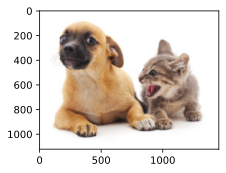

In [11]:
d2l.set_figsize()
print('input image shape:', img.permute(1, 2, 0).shape)
d2l.plt.imshow(img.permute(1, 2, 0));
print('output image shape:', out_img.shape)
d2l.plt.imshow(out_img);

In [12]:
W = bilinear_kernel(num_classes, num_classes, 64)
net.transpose_conv.weight.data.copy_(W);

##### 13.11.3 读取数据集
指定随即裁剪的输出图像的大小为(320,480)，高和宽均可以被32整除。

In [13]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = d2l.load_data_voc(batch_size, crop_size)

read 1114 examples
read 1078 examples


##### 13.11.4 训练

In [ ]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd, device = 5, 0.001, 1e-3, [torch.device('mps')]
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)

loss 0.412, train acc 0.871, test acc 0.851
101.8 examples/sec on [device(type='mps')]


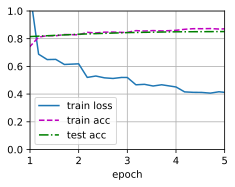

In [31]:
d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device)

loss 0.215, train acc 0.927, test acc 0.861
106.6 examples/sec on [device(type='mps')]


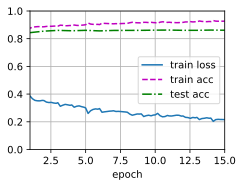

In [32]:
def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

num_epochs, lr, wd, device = 15, 0.001, 1e-3, [torch.device('mps')]
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)

d2l.train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, device)

##### 13.11.5 预测
在预测是，需要将输入图像的各个通道进行标准化，转换成卷积神经网络所需的四维输入格式。

In [40]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    model = net.module if hasattr(net, "module") else net
    pred = model(X.to(device[0])).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [41]:
def label2image(pred):
    colormap = torch.tensor(d2l.VOC_COLORMAP, device=device[0])
    X = pred.long()
    return colormap[X, :]

In [42]:
print(device)
print(type(device))

[device(type='mps')]
<class 'list'>


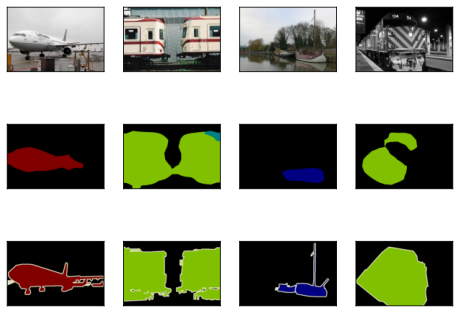

In [43]:
voc_dir = d2l.download_extract('voc2012', 'VOCdevkit/VOC2012')
test_images, test_labels = d2l.read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
d2l.show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2);